In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet("./data/diversity_utilities")
df

Human-Ranking,Algo-Ranking,Utility,Distance,Uses-Human-Utility,Human-Beta,Algorithm-Beta,Algorithm-Alpha,Algorithm-Sigma
list[i64],list[i64],f64,i64,bool,f64,f64,f64,f64
"[5, 8, … 10]","[5, 8, … 10]",0.794925,0,true,1.5,1.5,0.85,1.5
"[8, 3, … 10]","[8, 3, … 10]",0.793643,0,true,1.5,1.5,0.85,1.5
"[8, 3, … 7]","[8, 3, … 7]",0.793629,0,true,1.5,1.5,0.85,1.5
"[8, 3, … 7]","[8, 3, … 7]",0.793629,0,true,1.5,1.5,0.85,1.5
"[2, 8, … 10]","[2, 8, … 10]",0.793647,0,true,1.5,1.5,0.85,1.5
…,…,…,…,…,…,…,…,…
"[8, 3, … 10]","[8, 6, … 2]",0.826157,9,true,1.5,1.5,0.0,1.5
"[8, 3, … 10]","[8, 6, … 10]",0.826157,9,true,1.5,1.5,0.0,1.5
"[8, 3, … 10]","[8, 3, … 10]",0.799351,9,true,1.5,1.5,0.0,1.5


In [3]:
df.filter(
    pl.col("Utility") == pl.col("Utility").max()
)

Human-Ranking,Algo-Ranking,Utility,Distance,Uses-Human-Utility,Human-Beta,Algorithm-Beta,Algorithm-Alpha,Algorithm-Sigma
list[i64],list[i64],f64,i64,bool,f64,f64,f64,f64
"[8, 3, … 10]","[8, 10, … 1]",0.84327,18,true,1.5,1.5,0.0,1.5
"[8, 1, … 10]","[8, 10, … 5]",0.84327,18,true,1.5,1.5,0.0,1.5
"[3, 8, … 10]","[3, 10, … 5]",0.84327,18,true,1.5,1.5,0.0,1.5
"[8, 6, … 7]","[8, 7, … 10]",0.84327,18,true,1.5,1.5,0.0,1.5
"[2, 1, … 8]","[2, 8, … 5]",0.84327,18,true,1.5,1.5,0.0,1.5
…,…,…,…,…,…,…,…,…
"[6, 5, … 9]","[6, 9, … 5]",0.84327,27,true,1.5,1.5,0.0,1.5
"[8, 5, … 7]","[8, 7, … 5]",0.84327,27,true,1.5,1.5,0.0,1.5
"[6, 5, … 9]","[6, 9, … 2]",0.84327,27,true,1.5,1.5,0.0,1.5


In [4]:
df.filter(
    pl.col("Utility") == pl.col("Utility").min()
)

Human-Ranking,Algo-Ranking,Utility,Distance,Uses-Human-Utility,Human-Beta,Algorithm-Beta,Algorithm-Alpha,Algorithm-Sigma
list[i64],list[i64],f64,i64,bool,f64,f64,f64,f64
"[5, 8, … 9]","[9, 6, … 5]",0.01962,27,false,1.5,1.5,0.85,1.5


In [5]:
df["Utility"].max()

0.8432704200782205

In [6]:
distance_counts = df["Distance"].value_counts()

with pl.Config(tbl_rows=-1):
    print(distance_counts)

shape: (6, 2)
┌──────────┬─────────┐
│ Distance ┆ count   │
│ ---      ┆ ---     │
│ i64      ┆ u32     │
╞══════════╪═════════╡
│ 27       ┆ 2854704 │
│ 36       ┆ 201888  │
│ 45       ┆ 32      │
│ 18       ┆ 6214392 │
│ 9        ┆ 1855496 │
│ 0        ┆ 640     │
└──────────┴─────────┘


In [137]:
temp_df = df.filter(
    pl.col("Uses-Human-Utility") == True,
    #pl.col("Distance").is_in([0, 9]),
    #pl.col("Algorithm-Alpha") == 0.85
).with_columns(
    ("Hβ: " + pl.concat_str([
        pl.col("Human-Beta"),
        pl.col("Algorithm-Alpha")
    ], separator=" x Aα: ")).alias("section"),
    ("Distance " + pl.col("Distance").cast(pl.String)).alias("Distance")
)

temp_df

Human-Ranking,Algo-Ranking,Utility,Distance,Uses-Human-Utility,Human-Beta,Algorithm-Beta,Algorithm-Alpha,Algorithm-Sigma,section
list[i64],list[i64],f64,str,bool,f64,f64,f64,f64,str
"[5, 8, … 10]","[5, 8, … 10]",0.794925,"""Distance 0""",true,1.5,1.5,0.85,1.5,"""Hβ: 1.5 x Aα: 0.85"""
"[8, 3, … 10]","[8, 3, … 10]",0.793643,"""Distance 0""",true,1.5,1.5,0.85,1.5,"""Hβ: 1.5 x Aα: 0.85"""
"[8, 3, … 7]","[8, 3, … 7]",0.793629,"""Distance 0""",true,1.5,1.5,0.85,1.5,"""Hβ: 1.5 x Aα: 0.85"""
"[8, 3, … 7]","[8, 3, … 7]",0.793629,"""Distance 0""",true,1.5,1.5,0.85,1.5,"""Hβ: 1.5 x Aα: 0.85"""
"[2, 8, … 10]","[2, 8, … 10]",0.793647,"""Distance 0""",true,1.5,1.5,0.85,1.5,"""Hβ: 1.5 x Aα: 0.85"""
…,…,…,…,…,…,…,…,…,…
"[8, 3, … 10]","[8, 6, … 2]",0.826157,"""Distance 9""",true,1.5,1.5,0.0,1.5,"""Hβ: 1.5 x Aα: 0.0"""
"[8, 3, … 10]","[8, 6, … 10]",0.826157,"""Distance 9""",true,1.5,1.5,0.0,1.5,"""Hβ: 1.5 x Aα: 0.0"""
"[8, 3, … 10]","[8, 3, … 10]",0.799351,"""Distance 9""",true,1.5,1.5,0.0,1.5,"""Hβ: 1.5 x Aα: 0.0"""


In [133]:
temp_df["section"].value_counts()

section,count
str,u32
"""Hβ: 1.5 x Aα: 0.0""",1390894
"""Hβ: 0.5 x Aα: 0.85""",1390894
"""Hβ: 0.5 x Aα: 0.0""",1390894
"""Hβ: 1.5 x Aα: 0.85""",1390894


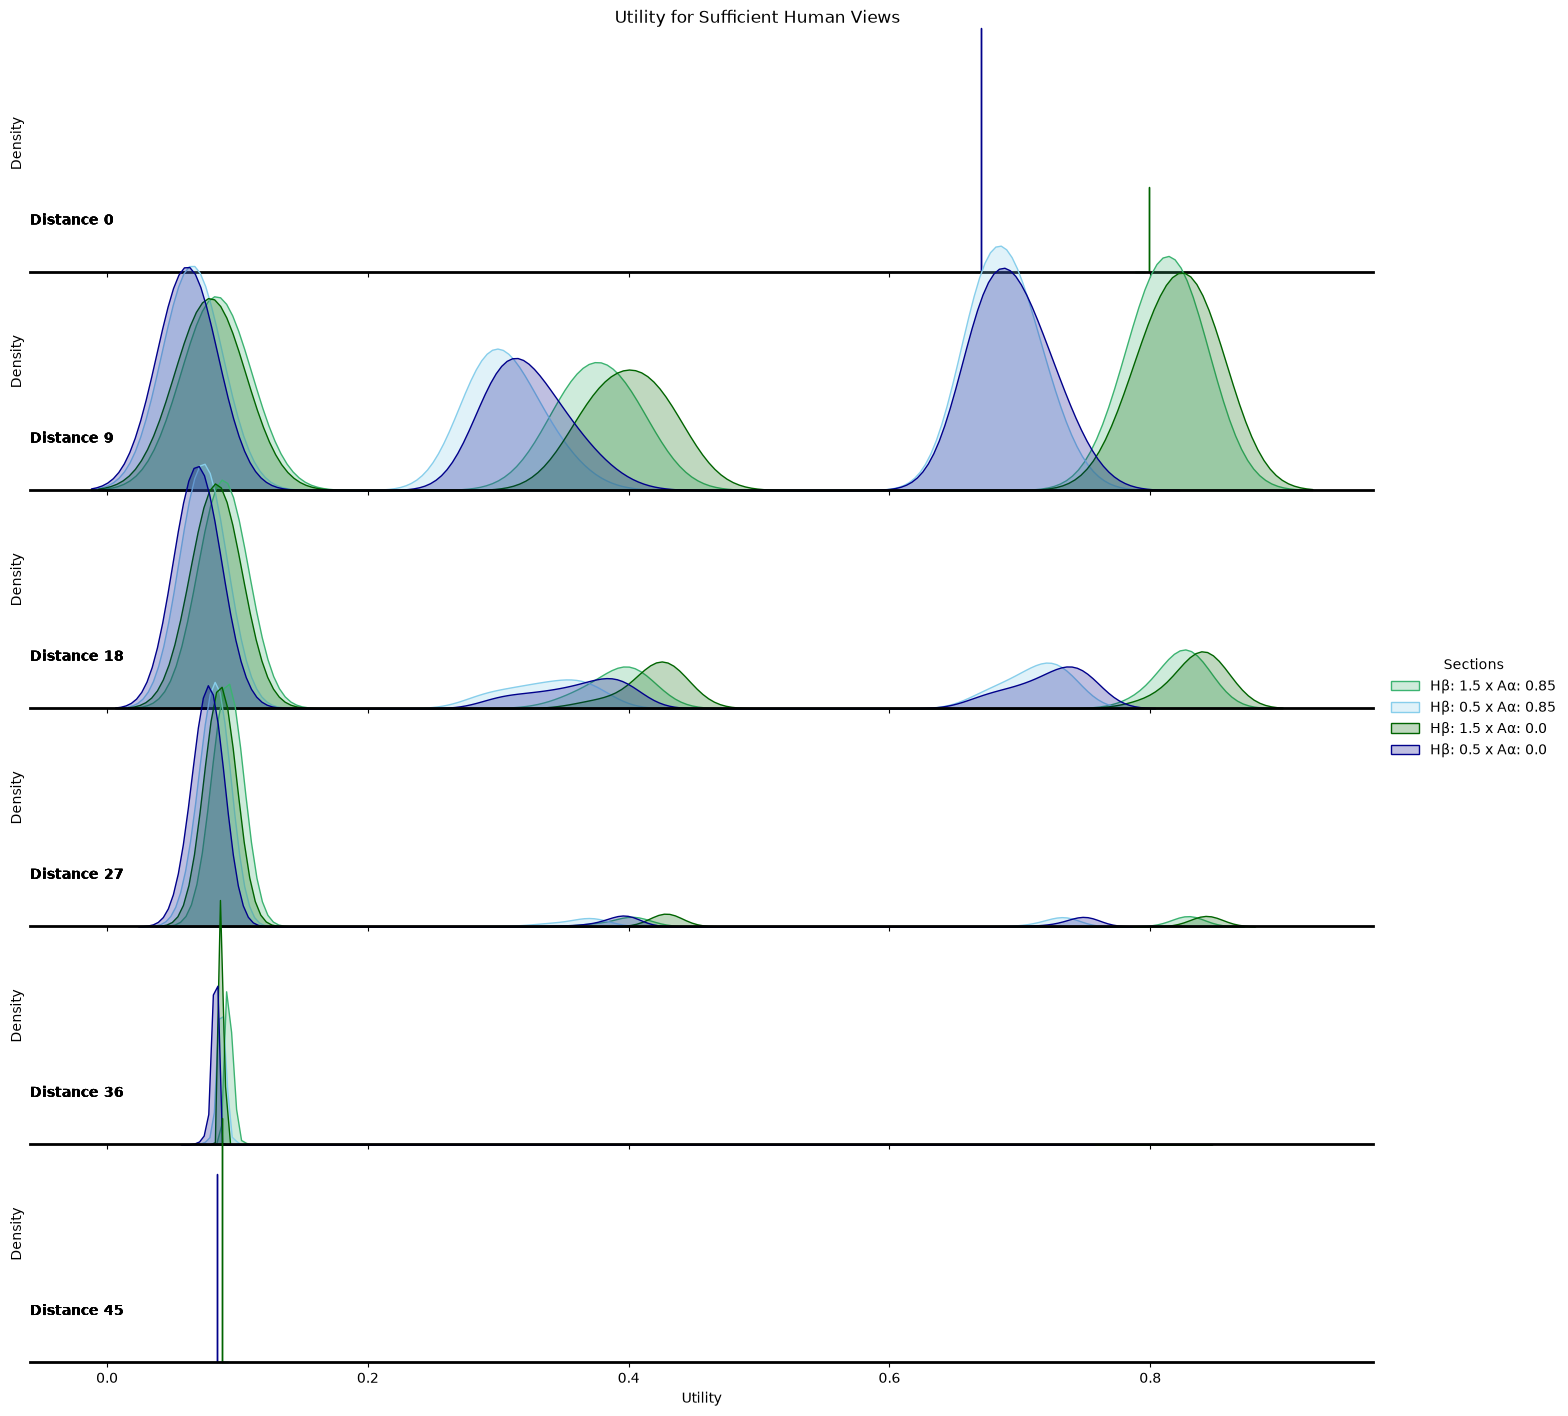

In [138]:
g = sns.FacetGrid(
    temp_df, row="Distance", aspect=6, height=2.4,
    row_order=[f"Distance {d}" for d in range(0, 46, 9)],
    #sharex=False, 
    sharey=False,
    hue="section", 
    hue_order=["Hβ: 1.5 x Aα: 0.85", "Hβ: 0.5 x Aα: 0.85", "Hβ: 1.5 x Aα: 0.0", "Hβ: 0.5 x Aα: 0.0"],
    palette=['mediumseagreen', 'skyblue', 'darkgreen', 'darkblue']
)

g.map_dataframe(
    sns.kdeplot, "Utility", fill=True, clip_on=False
)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, x.iloc[0], fontweight="bold", color='black',
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "Distance")

for ax in g.axes.flat:
    ax.axhline(y=0, lw=2, clip_on=False, color="black")
    ax.set_facecolor("none")

g.figure.subplots_adjust(hspace=-.15)

g.set_titles("")
g.figure.suptitle("Utility for Sufficient Human Views")
g.set(yticks=[], xlabel="")
g.set_xlabels("Utility")
g.despine(bottom=True, left=True)

g.add_legend(title="Sections")

plt.show()

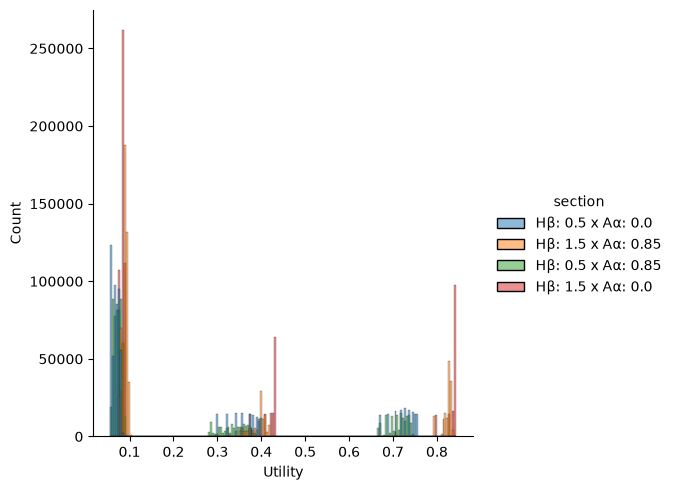

In [9]:
sns.displot(
    temp_df, x="Utility", hue="section", 
    #binwidth=0.005
)

#plt.xlim(0, 1)
plt.show()

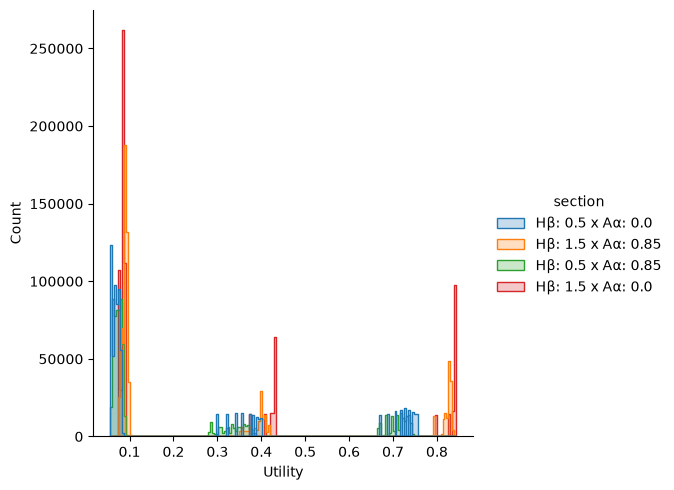

In [10]:
sns.displot(
    temp_df, x="Utility", hue="section", element="step", 
    #binwidth=0.005
)

#plt.xlim(0, 1)
plt.show()

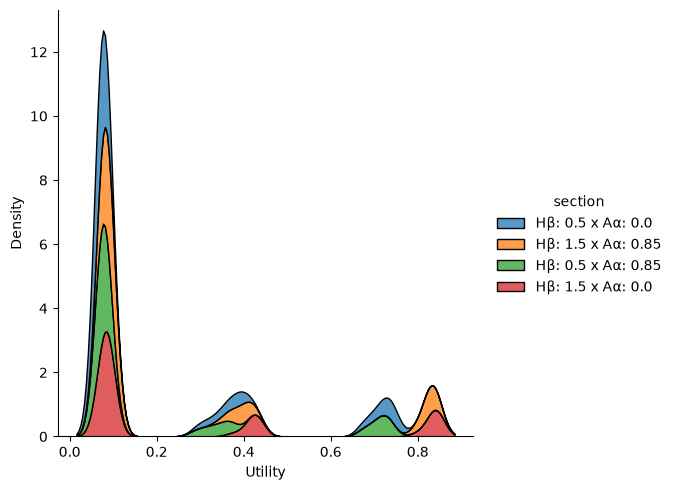

In [11]:
sns.displot(
    temp_df, x="Utility", hue="section", kind="kde", multiple="stack", 
    #bw_adjust=.05
)
plt.show()

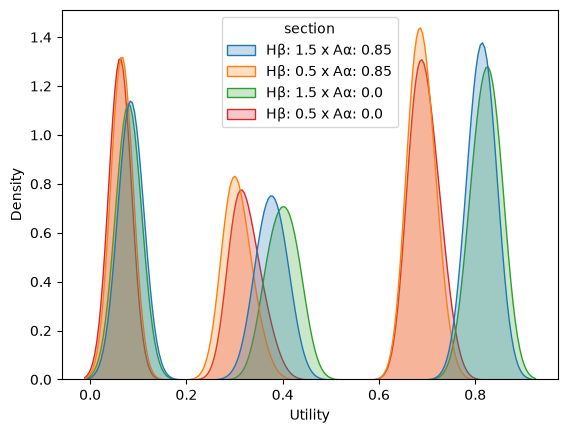

In [31]:
sns.kdeplot(
    temp_df, x="Utility", hue="section", fill=True, 
    #bw_adjust=.05
)
plt.show()

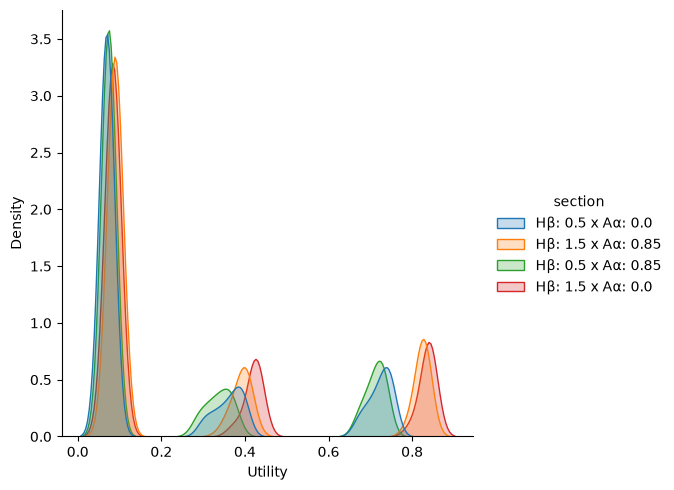

In [12]:
sns.displot(
    temp_df, x="Utility", hue="section", kind="kde", fill=True, 
    #bw_adjust=.05
)
plt.show()

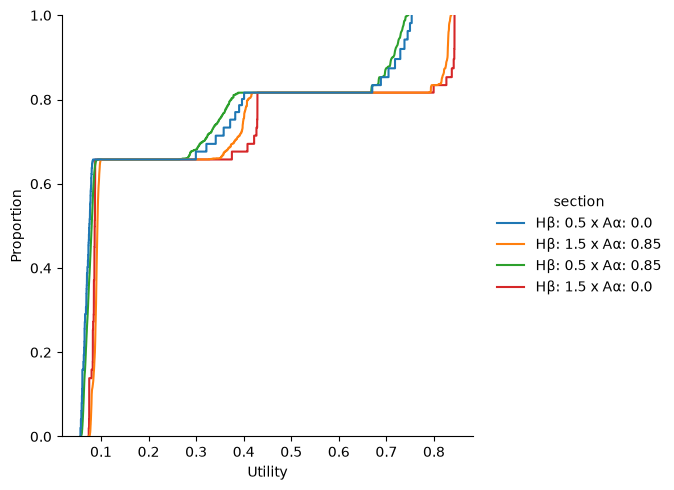

In [9]:
sns.displot(temp_df, x="Utility", hue="section", kind="ecdf")
plt.show()